In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Neural circuits of spontaneous activity

In this notebook we will use simple neural circuit models to explore how spontaneous activity can emerge from recurrent interactions, intrinsic cellular mechanisms, and noise. The goal is not to build a biophysically complete model, but to understand the circuit logic behind ongoing activity in neural populations.

We will keep the simulations deliberately simple. Most models will be first-order differential equations discretized with the Euler method, as in the attractor notebook:

$$
x(t+dt) = x(t) + \frac{dt}{\tau} F(x(t), I(t))
$$

Before adding circuit mechanisms one by one, we define a few helper functions that we will reuse throughout the exercises.

In [17]:
def rectify(x, threshold=0):
    return (x - threshold) * (x > threshold)


def make_time(T=5, dt=0.001):
    time = np.arange(0, T, dt)
    return time, len(time)


def make_step_rate(time, steps, baseline=0):
    rate = baseline * np.ones_like(time)
    for start, stop, amplitude in steps:
        rate[(time >= start) & (time < stop)] = amplitude
    return rate


def plot_input_output(time, input_current, output, output_label='rate'):
    fig, ax = plt.subplots(nrows=2, sharex=True)
    ax[0].plot(time, input_current, 'k')
    ax[0].set_title('Input')
    ax[0].set_ylabel('current')
    ax[1].plot(time, output, 'r')
    ax[1].set_title('Output')
    ax[1].set_xlabel('time (s)')
    ax[1].set_ylabel(output_label)
    plt.tight_layout()

# Exercise 1

We now build a recurrent excitatory-inhibitory network. The excitatory population receives recurrent excitation and inhibition, while the inhibitory population receives excitation from the excitatory population and recurrent inhibition.

The network receives external inputs $I_E$ and $I_I$ to the excitatory and inhibitory populations, respectively:

$$
\tau_E \frac{d r_E}{dt} = -r_E + f(W_{EE} r_E - W_{EI} r_I + I_E)
$$

$$
\tau_I \frac{d r_I}{dt} = -r_I + f(W_{IE} r_E - W_{II} r_I + I_I)
$$

Here $f(\cdot)$ is a rectified transfer function with a maximum firing rate. This saturation is useful because otherwise strong recurrent excitation can produce unrealistically large rates.

After simulating the time evolution of the network, we use phase-plane analysis to plot the nullclines. The nullclines show where $dr_E/dt = 0$ and $dr_I/dt = 0$. Their intersections are fixed points of the dynamics.

In [ ]:
# ============================================================
# Exercise 3: recurrent excitatory-inhibitory (EI) network
# ============================================================
#
# In this exercise we simulate two interacting neural populations:
#
#   rE(t): firing rate of the excitatory population
#   rI(t): firing rate of the inhibitory population
#
# The E population excites itself and the I population.
# The I population inhibits the E population and itself.
#
# We will do two things:
#   1. Simulate rE(t) and rI(t) through time.
#   2. Plot the phase plane: vector field + nullclines.

# -------------------------
# Simulation time
# -------------------------
# dt is the time step of the Euler simulation, in seconds.
# T is the total duration of the simulation, in seconds.
dt = 0.001
time, Nt = make_time(T=5, dt=dt)

# -------------------------
# External inputs
# -------------------------
# I_E is a constant external input current to the excitatory population.
# I_I is a constant external input current to the inhibitory population.
# Try changing these values and observe how the fixed point moves.
I_E = 0.4
I_I = 0.2

# -------------------------
# Time constants
# -------------------------
# tauE and tauI determine how quickly each population changes its rate.
# Here inhibition is faster than excitation, which is common in simple rate models.
tauE = 0.05
tauI = 0.01

# -------------------------
# Connectivity strengths
# -------------------------
# WEE: E -> E recurrent excitation
# WEI: I -> E inhibition. This number is positive, but it is subtracted below.
# WIE: E -> I excitation
# WII: I -> I recurrent inhibition. This number is positive, but it is subtracted below.
WEE = 1.0
WEI = 0.4
WIE = 1.0
WII = 0.3

# -------------------------
# Transfer function parameters
# -------------------------
# The transfer function converts total input current into output firing rate.
# It is rectified, meaning negative inputs produce zero output.
# It is also saturated, meaning rates cannot grow above r_max.
threshold = 0.0
gain = 10
r_max = 50

def saturating_rectify(x, threshold=0, gain=1, r_max=80):
    # First apply a threshold-linear function: gain * (x - threshold).
    # np.maximum(..., 0) implements rectification, so values below threshold become 0.
    y = gain * np.maximum(x - threshold, 0)

    # Then apply saturation, so the firing rate never exceeds r_max.
    return np.minimum(y, r_max)

# -------------------------
# Initialize the rate variables
# -------------------------
# rE and rI store the full time course of the excitatory and inhibitory rates.
# Both populations start silent here, but the external input will move them away from zero.
rE = np.zeros((Nt,))
rI = np.zeros((Nt,))

# -------------------------
# Euler simulation loop
# -------------------------
# At each time step we:
#   1. Compute the total input to E and I.
#   2. Pass that input through the transfer function.
#   3. Update rE and rI using Euler's method.
for i in range(Nt - 1):
    # Total input to the excitatory population:
    # recurrent excitation - inhibition + external input.
    input_E = WEE*rE[i] - WEI*rI[i] + I_E

    # Total input to the inhibitory population:
    # excitation from E - recurrent inhibition + external input.
    input_I = WIE*rE[i] - WII*rI[i] + I_I

    # Desired rates according to the transfer function.
    target_E = saturating_rectify(input_E, threshold, gain, r_max)
    target_I = saturating_rectify(input_I, threshold, gain, r_max)

    # Euler update of the two differential equations.
    rE[i+1] = rE[i] + dt/tauE * (-rE[i] + target_E)
    rI[i+1] = rI[i] + dt/tauI * (-rI[i] + target_I)

# -------------------------
# Plot the simulated time courses
# -------------------------
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(7, 5))

ax[0].plot(time, rE, 'r', label='E population')
ax[0].plot(time, rI, 'b', label='I population')
ax[0].set_ylabel('rate')
ax[0].set_title('EI network simulation')
ax[0].legend()

ax[1].plot(time, I_E*np.ones_like(time), 'r', label='$I_E$')
ax[1].plot(time, I_I*np.ones_like(time), 'b', label='$I_I$')
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('external input')
ax[1].legend()

plt.tight_layout();

# ============================================================
# Phase-plane analysis
# ============================================================
#
# The phase plane represents the state of the network as a point (rE, rI).
# For each point in this plane we compute:
#
#   dRE = drE/dt
#   dRI = drI/dt
#
# The vector (dRE, dRI) tells us where the activity will move next.
# Nullclines are the curves where one of these derivatives is zero.
#   red nullcline:  drE/dt = 0
#   blue nullcline: drI/dt = 0

# -------------------------
# Range and spacing of the phase-plane grids
# -------------------------
# We use two different grids:
#   vector_grid_step: coarse grid for the arrows, so the vector field is readable.
#   nullcline_grid_step: fine grid for the nullclines, so the curves are smooth.
r_E_min = -1
r_E_max = 5
r_I_min = -1
r_I_max = 10
vector_grid_step = 0.5
nullcline_grid_step = 0.05

# -------------------------
# Coarse grid for the vector field
# -------------------------
rE_vector_axis = np.arange(r_E_min, r_E_max + vector_grid_step, vector_grid_step)
rI_vector_axis = np.arange(r_I_min, r_I_max + vector_grid_step, vector_grid_step)
RE_vector, RI_vector = np.meshgrid(rE_vector_axis, rI_vector_axis)

# -------------------------
# Fine grid for the nullclines
# -------------------------
rE_nullcline_axis = np.arange(r_E_min, r_E_max + nullcline_grid_step, nullcline_grid_step)
rI_nullcline_axis = np.arange(r_I_min, r_I_max + nullcline_grid_step, nullcline_grid_step)
RE_nullcline, RI_nullcline = np.meshgrid(rE_nullcline_axis, rI_nullcline_axis)

# -------------------------
# Compute derivatives on the vector-field grid
# -------------------------
# These derivatives define the arrows shown in the phase plane.
input_E_vector = WEE*RE_vector - WEI*RI_vector + I_E
input_I_vector = WIE*RE_vector - WII*RI_vector + I_I

target_E_vector = saturating_rectify(input_E_vector, threshold, gain, r_max)
target_I_vector = saturating_rectify(input_I_vector, threshold, gain, r_max)

dRE_vector = (-RE_vector + target_E_vector) / tauE
dRI_vector = (-RI_vector + target_I_vector) / tauI

# -------------------------
# Compute derivatives on the nullcline grid
# -------------------------
# These derivatives define smooth contour lines where drE/dt = 0 or drI/dt = 0.
input_E_nullcline = WEE*RE_nullcline - WEI*RI_nullcline + I_E
input_I_nullcline = WIE*RE_nullcline - WII*RI_nullcline + I_I

target_E_nullcline = saturating_rectify(input_E_nullcline, threshold, gain, r_max)
target_I_nullcline = saturating_rectify(input_I_nullcline, threshold, gain, r_max)

dRE_nullcline = (-RE_nullcline + target_E_nullcline) / tauE
dRI_nullcline = (-RI_nullcline + target_I_nullcline) / tauI

# -------------------------
# Normalize vectors for plotting
# -------------------------
# The derivatives can be very large in some parts of the plane.
# Normalizing lets us show the direction of flow clearly everywhere.
# arrow_length controls how long the displayed arrows look.
speed_vector = np.sqrt(dRE_vector**2 + dRI_vector**2)
speed_vector[speed_vector == 0] = 1
arrow_length = 0.38
u = arrow_length * dRE_vector / speed_vector
v = arrow_length * dRI_vector / speed_vector

# Approximate fixed point: point on the fine nullcline grid where the speed is smallest.
# This is only an approximation because we evaluate the dynamics on a grid.
speed_nullcline = np.sqrt(dRE_nullcline**2 + dRI_nullcline**2)
fixed_i, fixed_j = np.unravel_index(np.argmin(speed_nullcline), speed_nullcline.shape)

# -------------------------
# Plot vector field, nullclines, and trajectory
# -------------------------
plt.figure(figsize=(6, 6))

# Flow field, plotted on the coarse grid.
plt.quiver(RE_vector, RI_vector, u, v, color='0.65', angles='xy', scale_units='xy', scale=1, width=0.004)

# Nullclines, plotted on the fine grid.
plt.contour(RE_nullcline, RI_nullcline, dRE_nullcline, levels=[0], colors='r', linewidths=2)
plt.contour(RE_nullcline, RI_nullcline, dRI_nullcline, levels=[0], colors='b', linewidths=2)

# Approximate fixed point and simulated trajectory.
plt.plot(RE_nullcline[fixed_i, fixed_j], RI_nullcline[fixed_i, fixed_j], 'ko', label='approx. fixed point')
plt.plot(rE, rI, 'k', lw=2, label='trajectory')

plt.xlabel('$r_E$')
plt.ylabel('$r_I$')
plt.xlim([r_E_min, r_E_max])
plt.ylim([r_I_min, r_I_max])
plt.gca().set_box_aspect(1)
plt.legend()
plt.tight_layout();


# Exercise 2

In Exercise 1 we simulated one excitatory-inhibitory network for one set of parameters. Here we use the same model to ask a more experimental question: what happens if we change one parameter while keeping all the others fixed?

Choose one parameter of the network, assign it three different values, and run the same simulation three times. This lets us compare how the time course and the phase-plane structure change as that parameter is varied.

For example, increasing $W_{EE}$ strengthens recurrent excitation in the excitatory population. This can move the fixed point, change the transient trajectory, or push the network toward a high-activity regime.

The code below plots two summaries for the three parameter values:

1. The time courses $r_E(t)$ and $r_I(t)$.
2. The nullclines and simulated trajectory in the phase plane.

The vector field is omitted here so that we can focus on how the nullclines and trajectories change across parameter values.

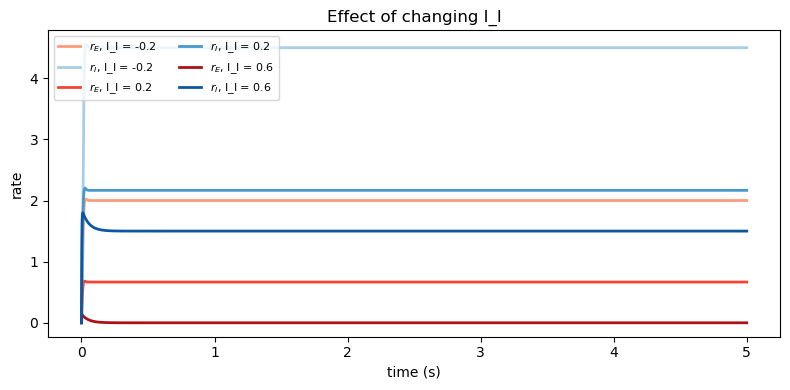

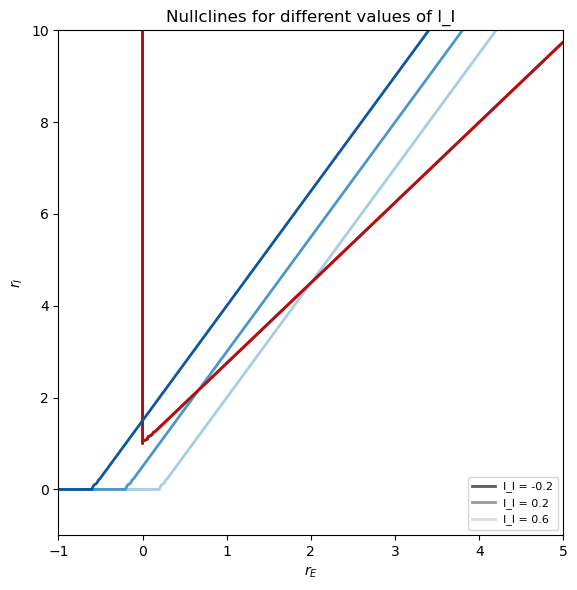

In [48]:
# ============================================================
# Exercise 4: parameter exploration in the EI network
# ============================================================
#
# In this exercise we take the EI network from Exercise 3 and run it
# three times while changing one parameter.
#
# To explore a different parameter, change parameter_name and parameter_values.
# Examples of parameter_name: 'WEE', 'WEI', 'WIE', 'WII', 'I_E', 'I_I',
#                             'tauE', 'tauI', 'gain', 'threshold', 'r_max'

# -------------------------
# Choose the parameter to vary
# -------------------------
parameter_name = 'I_I'
parameter_values = [-0.2, 0.2, 0.6]

# -------------------------
# Simulation time
# -------------------------
dt = 0.001
time, Nt = make_time(T=5, dt=dt)

# -------------------------
# Default model parameters
# -------------------------
# These are the baseline parameters of the EI network.
# During the parameter sweep, one of these values will be replaced by
# each value in parameter_values.
default_params = {
    'I_E': 0.4,
    'I_I': 0.2,
    'tauE': 0.05,
    'tauI': 0.01,
    'WEE': 0.8,
    'WEI': 0.4,
    'WIE': 1.0,
    'WII': 0.3,
    'threshold': 0.0,
    'gain': 10,
    'r_max': 50,
}

def saturating_rectify(x, threshold=0, gain=1, r_max=80):
    # Rectified and saturating transfer function.
    # Inputs below threshold give zero output.
    # Inputs above threshold increase linearly with slope 'gain'.
    # The output is capped at r_max.
    y = gain * np.maximum(x - threshold, 0)
    return np.minimum(y, r_max)

def simulate_ei_network(params, time, dt):
    # This function runs one EI-network simulation for one parameter set.
    Nt = len(time)
    rE = np.zeros((Nt,))
    rI = np.zeros((Nt,))

    for i in range(Nt - 1):
        # Total input currents to the E and I populations.
        input_E = params['WEE']*rE[i] - params['WEI']*rI[i] + params['I_E']
        input_I = params['WIE']*rE[i] - params['WII']*rI[i] + params['I_I']

        # Convert input currents into target firing rates.
        target_E = saturating_rectify(input_E, params['threshold'], params['gain'], params['r_max'])
        target_I = saturating_rectify(input_I, params['threshold'], params['gain'], params['r_max'])

        # Euler update of the two rate equations.
        rE[i+1] = rE[i] + dt/params['tauE'] * (-rE[i] + target_E)
        rI[i+1] = rI[i] + dt/params['tauI'] * (-rI[i] + target_I)

    return rE, rI

def compute_nullclines(params, r_E_min=-1, r_E_max=5, r_I_min=-1, r_I_max=10, grid_step=0.05):
    # Compute drE/dt and drI/dt over a fine grid.
    # The red nullcline is where dRE = 0.
    # The blue nullcline is where dRI = 0.
    rE_axis = np.arange(r_E_min, r_E_max + grid_step, grid_step)
    rI_axis = np.arange(r_I_min, r_I_max + grid_step, grid_step)
    RE, RI = np.meshgrid(rE_axis, rI_axis)

    input_E = params['WEE']*RE - params['WEI']*RI + params['I_E']
    input_I = params['WIE']*RE - params['WII']*RI + params['I_I']

    target_E = saturating_rectify(input_E, params['threshold'], params['gain'], params['r_max'])
    target_I = saturating_rectify(input_I, params['threshold'], params['gain'], params['r_max'])

    dRE = (-RE + target_E) / params['tauE']
    dRI = (-RI + target_I) / params['tauI']

    return RE, RI, dRE, dRI

# -------------------------
# Run the three simulations
# -------------------------
# Each entry in results will contain the parameter value, the parameters used,
# and the resulting E and I time courses.
results = []

for value in parameter_values:
    params = default_params.copy()
    params[parameter_name] = value
    rE, rI = simulate_ei_network(params, time, dt)
    results.append({'value': value, 'params': params, 'rE': rE, 'rI': rI})

# -------------------------
# Plot rates as a function of time
# -------------------------
# Solid lines are excitatory rates.
# Dashed lines are inhibitory rates.
colors = ['tab:green', 'tab:orange', 'tab:purple']
colors_E = plt.cm.Reds([0.35, 0.6, 0.85])
colors_I = plt.cm.Blues([0.35, 0.6, 0.85])
grays = plt.cm.gray([0.35, 0.6, 0.85])

plt.figure(figsize=(8, 4))
for result, color_e, color_i in zip(results, colors_E, colors_I):
    label = f"{parameter_name} = {result['value']}"
    plt.plot(time, result['rE'], color=color_e, lw=2, label='$r_E$, ' + label)
    plt.plot(time, result['rI'], color=color_i, lw=2,  label='$r_I$, ' + label)

plt.xlabel('time (s)')
plt.ylabel('rate')
plt.title(f'Effect of changing {parameter_name}')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout();

# -------------------------
# Plot all nullclines in the same phase plane
# -------------------------
# We now overlay the nullclines from the three parameter values in one plot.
# This makes it easier to see how changing the parameter shifts the geometry
# of the phase plane.
#
# Solid line: E nullcline, where drE/dt = 0.
# Dashed line: I nullcline, where drI/dt = 0.
# Color: parameter value.
r_E_min = -1
r_E_max = 5
r_I_min = -1
r_I_max = 10
nullcline_grid_step = 0.05

plt.figure(figsize=(6, 6))

for result, color_e, color_i, color in zip(results, colors_E, colors_I, grays):
    params = result['params']
    RE, RI, dRE, dRI = compute_nullclines(
        params,
        r_E_min=r_E_min,
        r_E_max=r_E_max,
        r_I_min=r_I_min,
        r_I_max=r_I_max,
        grid_step=nullcline_grid_step,
    )

    # E nullcline: where drE/dt = 0.
    plt.contour(RE, RI, dRE, levels=[0], colors=[color_e], linewidths=2, linestyles='solid')

    # I nullcline: where drI/dt = 0.
    plt.contour(RE, RI, dRI, levels=[0], colors=[color_i], linewidths=2, linestyles='solid')

    # Add invisible lines so the legend clearly identifies each parameter value.
    plt.plot([], [], color=color, lw=2, label=f"{parameter_name} = {result['value']}")

# Add black proxy lines explaining the line styles.
#plt.plot([], [], color='k', lw=2, ls='solid', label='E nullcline')
#plt.plot([], [], color='k', lw=2, ls='dashed', label='I nullcline')

plt.xlabel('$r_E$')
plt.ylabel('$r_I$')
plt.title(f'Nullclines for different values of {parameter_name}')
plt.xlim([r_E_min, r_E_max])
plt.ylim([r_I_min, r_I_max])
plt.gca().set_box_aspect(1)
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout();


# Exercise 3

Now let's take the EI network from Excercise 1 and add adaptation to the E population. 

# Exercise 4

Now let's take the EI network from excercise 1 and add  noise in the input to each of the populations.  Parametrize the amplitude of the noise with parameters sigma_E and sigma_I. Parametrize the correlation of the input noise into the network with a parameter rho_EI. 

# Exercise 5

_Optional placeholder for a seventh exercise._

# Exercise 6

_Optional placeholder for an eighth exercise._

# Exercise 7

_Optional placeholder for a ninth exercise._